# Types of Gradient Descent

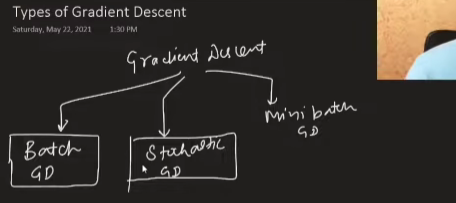

### What is the basis that there are different types of gradient descent?

- Suppose you have a dataset with 300 rows:

- For Batch Gradient Descent,:
    - You will go through all the 300 rows in one iteration to update the parameters (This is what we have been doing so far).
    - So you will update only once after going through all the 300 rows.

- For Stochastic Gradient Descent:
    - You will go through only 1 row in one iteration to update the parameters.
    - So you will update 300 times after going through all the 300 rows.

- For Mini-batch Gradient Descent: (You create batches of data, for example, 10 batches of 30 rows each)
    - You will go through only 30 rows in one iteration to update the parameters.
    - So you will update 10 times after going through all the 300 rows.


- Generally stochastic and mini-batch gradient descent are used....Batch gradient descent is rarely used...sometimes we use it when the loss function is **convex** and the data is **small**

- So, we alread learnt Batch Gradient Descent in 2D (one input and one output) so in this lesson we will see Batch gradient for multiple linear regression (multiple inputs and one output)

- For n-features (n-dimenson) data, we have $n+1$ optimizable parameters (n weights and 1 offset) 

# Mathematical formulation of n-dimensional Batch Gradient Descent

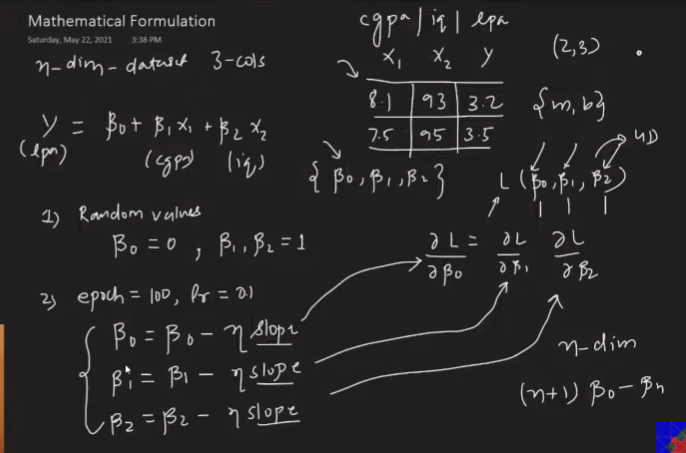

- For now we took 2 input features (cgpa,iq), so we have 3 parameters ($\beta_0, \beta_1, \beta_2$) to optimize

- Step 1: We initialize the parameters with some random values (for example, $\beta_0=0, \beta_1=1, \beta_2=1$) {Generally we initialize weights with 1 and offset with 0}

- Step 2: Use Gradient descent formula to update the parameters:
$$\beta_j = \beta_j - \eta \frac{\partial L(\beta_0, \beta_1, \beta_2)}{\partial \beta_j}$$



- Partial derivative of the loss function with respect to $\beta_0$ is given by:

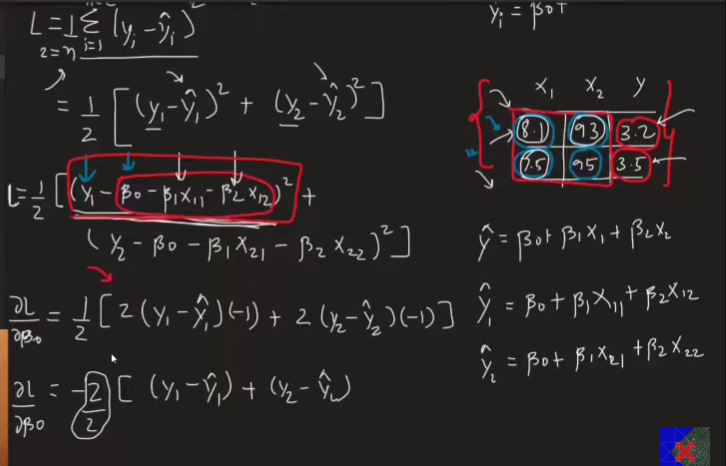

- If there would be $n$ rows instead of 2 then the formula would be:

    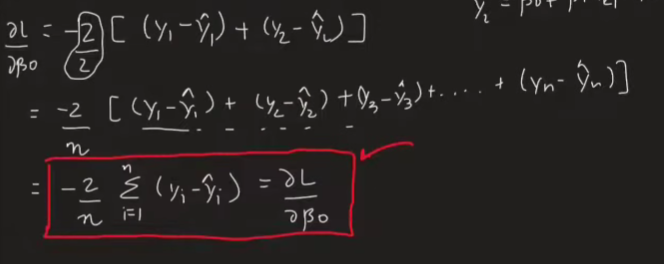

- Partial derivative of the loss function with respect to $\beta_1$ is given by:

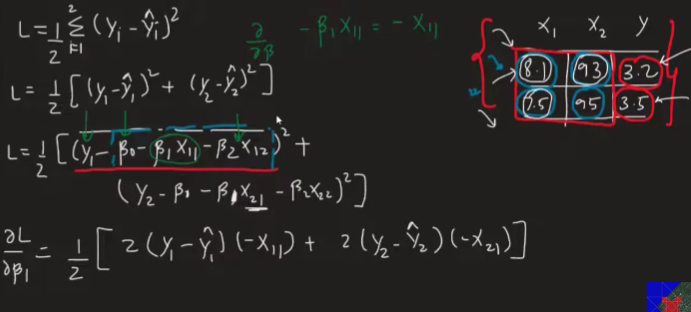

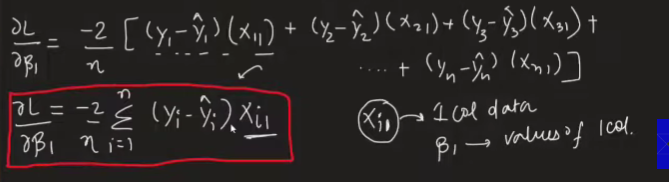

- Similarly partial derivative of the loss function with respect to $\beta_2$ will be:

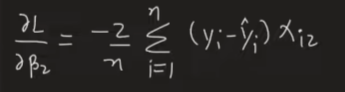

- General formula for partial derivative of the loss function with respect to $\beta_j$ is given by:

### $\frac{\partial L}{\partial \beta_j} = -\frac{2}{n} \sum_{i=1}^{n} (y_i - \hat{y_i}) x_{ij}$

- where $n$: number of rows in the dataset
- $y_i$: actual output for the i-th row
- $\hat{y_i}$: predicted output for the i-th row
- Varying $i$ is giving summation over all the rows in the dataset
- $x_{ij}$: value of the j-th column for the i-th row

- Let's see the code now

In [1]:
from sklearn.datasets import load_diabetes

import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split

In [138]:
X,y = load_diabetes(return_X_y=True)

In [139]:
type(X), type(y)

(numpy.ndarray, numpy.ndarray)

In [140]:
print(X.shape)
print(y.shape)

(442, 10)
(442,)


In [141]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [142]:
reg = LinearRegression()
reg.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [143]:
print(reg.coef_)
print(reg.intercept_)

[  -9.15865318 -205.45432163  516.69374454  340.61999905 -895.5520019
  561.22067904  153.89310954  126.73139688  861.12700152   52.42112238]
151.88331005254167


In [144]:
y_pred = reg.predict(X_test)
r2_score(y_test,y_pred)

0.439933866156897

In [145]:
y_pred

array([154.1213881 , 204.81835118, 124.93755353, 106.08950893,
       258.5348576 , 256.3310074 , 118.75087616, 119.52440696,
       101.50816735, 190.54048661, 141.70656811, 172.51883961,
       174.33861649, 134.80942706, 294.13994537,  94.11798038,
       211.97059795, 156.49579378, 134.21000428, 119.62664644,
       148.87842251, 165.00873409, 151.10021038, 176.04063756,
       133.27769647, 221.29555392, 197.17324941,  96.1577688 ,
        50.26012711, 230.48580317, 242.06073866, 114.11129218,
        67.07532417,  94.52943825, 201.21415375, 167.05136201,
       159.881268  , 192.78746659, 114.49551325, 233.48234551,
       140.82563045, 121.0680409 , 192.27480772, 191.12738845,
       179.16865788, 148.34935601, 163.47414622, 276.81647884,
       100.17926432, 164.10555298, 255.80762189, 136.9466204 ,
       152.37503699, 107.92237882, 194.21924678,  77.34670792,
       118.50482479,  68.38335763, 154.29258529, 162.48840259,
       168.36788326, 156.87790322,  97.14191797, 238.16

In [146]:
X_train.shape

(353, 10)

In [147]:
np.ones(X_train.shape[1])

array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1.])

In [148]:
y_train.shape

(353,)

In [ ]:
# I implemented it myself, the commented code is the vectorized version, I wanted to do it without vectorization to understand the process better
class GDLinearRegression:
    def __init__(self,lr = 0.1,epochs = 1000):
        self.coef_ = None
        self.intercept_ = None
        self.learning_rate = lr
        self.epochs = epochs

    def fit(self,X,y):

        self.intercept_ = 0
        self.coef_ = np.ones(X.shape[1])

        for i in range(self.epochs):


            # y_hat = np.dot(X,self.coef_) + self.intercept_

            y_hat = []
            for j in range (y.shape[0]):
                y_hat.append(np.sum(self.coef_ * X[j,:]) + self.intercept_)



            # slope_intercept = - 2*np.mean(y - y_hat)

            slope_intercept = (- 2/X.shape[0])*np.sum(y - y_hat)
            self.intercept_ = self.intercept_ - self.learning_rate * slope_intercept

            

            # weigth_slope = -2 * np.dot((y - y_hat),X)/X.shape[0]
            # self.coef_ = self.coef_ - self.learning_rate * weigth_slope
            for k in range(self.coef_.shape[0]):

                weigth_slope = (- 2/X.shape[0]) * np.sum((y - y_hat)*X[:,k])
                self.coef_[k] = self.coef_[k] - self.learning_rate * weigth_slope

            
        
        print (self.intercept_,self.coef_)

    def predict(self,X):
        return np.dot(X,self.coef_) + self.intercept_
            



In [150]:
my_reg = GDLinearRegression()

In [151]:
my_reg.fit(X_train,y_train)

151.94042847773682 [  62.27835432  -24.14017912  262.40285385  192.20751489   39.48809013
   10.26886323 -142.50597903  124.33312557  244.33510843  119.34350233]


In [152]:
my_pred = my_reg.predict(X_test)

In [153]:
r2_score(y_test,my_pred)

0.3971698388048742

In [154]:
class GDRegressor:
    
    def __init__(self,learning_rate=0.1,epochs=200):
        
        self.coef_ = None
        self.intercept_ = None
        self.lr = learning_rate
        self.epochs = epochs
        
    def fit(self,X_train,y_train):
        # init your coefs
        self.intercept_ = 0
        self.coef_ = np.ones(X_train.shape[1])
        
        for i in range(self.epochs):
            # update all the coef and the intercept
            y_hat = np.dot(X_train,self.coef_) + self.intercept_
            #print("Shape of y_hat",y_hat.shape)
            intercept_der = -2 * np.mean(y_train - y_hat)
            self.intercept_ = self.intercept_ - (self.lr * intercept_der)
            
            coef_der = -2 * np.dot((y_train - y_hat),X_train)/X_train.shape[0]
            self.coef_ = self.coef_ - (self.lr * coef_der)
        
        print(self.intercept_,self.coef_)
    
    def predict(self,X_test):
        return np.dot(X_test,self.coef_) + self.intercept_

In [155]:
gdr = GDRegressor(epochs=200,learning_rate=0.1)

In [156]:
gdr.fit(X_train,y_train)

151.00676761350948 [ 27.99154295   4.50826894  77.97661096  60.18501877  25.1501166
  18.6591924  -46.9192828   49.7596329   76.29048725  45.397553  ]


In [157]:
y_pred = gdr.predict(X_test)

In [158]:
r2_score(y_test,y_pred)

0.1855342965431701